# Swish Analytics Data Modeling Challenge

## Objective
Predict the probability that an NFL pass play results in a sack using play-by-play, roster, depth chart, snap count, and advanced statistics data.

## Dataset Summary
- Training Seasons: 2021-2022
- Testing Season: 2023
- Play-by-play data
- Player roster data
- Depth chart data
- Snap count data
- Advanced statistics

## Approach
1. Explore the data
2. Define target variable
3. Build baseline model
4. Engineer football-specific features
5. Train advanced models
6. Evaluate and compare performance

# Data Exploration

In [228]:
import pandas as pd

players = pd.read_csv(
    "../data/NFL-20260612T145329Z-3-001/NFL/players.csv"
)

print(players.shape)
players.head()

(20753, 32)


,status,display_name,first_name,last_name,esb_id,gsis_id,birth_date,college_name,position_group,position,...,draftround,college_conference,status_description_abbr,status_short_description,gsis_it_id,short_name,smart_id,headshot,uniform_number,suffix
0,RET,'Omar Ellison,'Omar,Ellison,ELL711319,00-0004866,1971-10-08,NaN,WR,WR,...,NaN,NaN,NaN,NaN,NaN,NaN,3200454c-4c71-1319-728e-d49d3d236f8f,NaN,NaN,NaN
1,ACT,A'Shawn Robinson,A'Shawn,Robinson,ROB367960,00-0032889,1995-03-21,Alabama,DL,DE,...,2.0,Southeastern Conference,A01,Active,43335.0,A.Robinson,3200524f-4236-7960-bf20-bc060ac0f49c,https://static.www.nfl.com/image/upload/f_auto...,94,NaN
2,DEV,A.J. Arcuri,A.J.,Arcuri,ARC716900,00-0037845,1997-08-13,Michigan State,OL,T,...,7.0,Big Ten Conference,P01,Practice Squad,54726.0,A.Arcuri,32004152-4371-6900-5185-8cdd66b2ad11,https://static.www.nfl.com/image/upload/f_auto...,61,NaN
3,RES,A.J. Bouye,Arlandus,Bouye,BOU651714,00-0030228,1991-08-16,Central Florida,DB,CB,...,NaN,American Athletic Conference,R01,R/Injured,40688.0,A.Bouye,3200424f-5565-1714-cb38-07c822111a12,https://static.www.nfl.com/image/private/f_aut...,24,NaN
4,ACT,A.J. Brown,Arthur,Brown,BRO413223,00-0035676,1997-06-30,Mississippi,WR,WR,...,2.0,Southeastern Conference,A01,Active,47834.0,A.Brown,32004252-4f41-3223-e4c5-1e30dffa87f8,https://static.www.nfl.com/image/private/f_aut...,11,NaN


In [229]:
DATA_PATH = "../data/NFL-20260612T145329Z-3-001/NFL"

In [230]:
players.columns.tolist()

['status',
 'display_name',
 'first_name',
 'last_name',
 'esb_id',
 'gsis_id',
 'birth_date',
 'college_name',
 'position_group',
 'position',
 'jersey_number',
 'height',
 'weight',
 'years_of_experience',
 'team_abbr',
 'team_seq',
 'current_team_id',
 'football_name',
 'entry_year',
 'rookie_year',
 'draft_club',
 'draft_number',
 'draftround',
 'college_conference',
 'status_description_abbr',
 'status_short_description',
 'gsis_it_id',
 'short_name',
 'smart_id',
 'headshot',
 'uniform_number',
 'suffix']

In [231]:
DATA_PATH = "../data/NFL-20260612T145329Z-3-001/NFL"

pbp_2021 = pd.read_csv(f"{DATA_PATH}/play_by_play_2021.csv")
pbp_2022 = pd.read_csv(f"{DATA_PATH}/play_by_play_2022.csv")
pbp_2023 = pd.read_csv(f"{DATA_PATH}/play_by_play_2023.csv")

pbp = pd.concat(
    [pbp_2021, pbp_2022, pbp_2023],
    ignore_index=True
)

print(pbp.shape)

C:\Users\efriedman\AppData\Local\Temp\ipykernel_19232\1200466979.py:3: DtypeWarning: Columns (0: lateral_receiver_player_id, 1: lateral_receiver_player_name, 2: lateral_rusher_player_id, 3: lateral_rusher_player_name, 4: lateral_interception_player_id, 5: lateral_interception_player_name, 6: lateral_punt_returner_player_id, 7: lateral_punt_returner_player_name, 8: lateral_kickoff_returner_player_id, 9: lateral_kickoff_returner_player_name, 10: own_kickoff_recovery_player_id, 11: own_kickoff_recovery_player_name, 12: blocked_player_id, 13: blocked_player_name, 14: forced_fumble_player_2_team, 15: forced_fumble_player_2_player_id, 16: forced_fumble_player_2_player_name, 17: assist_tackle_3_player_id, 18: assist_tackle_3_player_name, 19: assist_tackle_3_team, 20: assist_tackle_4_player_id, 21: assist_tackle_4_player_name, 22: assist_tackle_4_team, 23: fumbled_2_player_id, 24: fumbled_2_player_name, 25: fumbled_2_team, 26: fumble_recovery_2_team, 27: fumble_recovery_2_player_id, 28: fumble

(149021, 372)


In [232]:
for col in pbp.columns:
    print(col)

play_id
game_id
old_game_id
home_team
away_team
season_type
week
posteam
posteam_type
defteam
side_of_field
yardline_100
game_date
quarter_seconds_remaining
half_seconds_remaining
game_seconds_remaining
game_half
quarter_end
drive
sp
qtr
down
goal_to_go
time
yrdln
ydstogo
ydsnet
desc
play_type
yards_gained
shotgun
no_huddle
qb_dropback
qb_kneel
qb_spike
qb_scramble
pass_length
pass_location
air_yards
yards_after_catch
run_location
run_gap
field_goal_result
kick_distance
extra_point_result
two_point_conv_result
home_timeouts_remaining
away_timeouts_remaining
timeout
timeout_team
td_team
td_player_name
td_player_id
posteam_timeouts_remaining
defteam_timeouts_remaining
total_home_score
total_away_score
posteam_score
defteam_score
score_differential
posteam_score_post
defteam_score_post
score_differential_post
no_score_prob
opp_fg_prob
opp_safety_prob
opp_td_prob
fg_prob
safety_prob
td_prob
extra_point_prob
two_point_conversion_prob
ep
epa
total_home_epa
total_away_epa
total_home_rush_epa


In [233]:
[col for col in pbp.columns if "sack" in col.lower()]

['sack',
 'lateral_sack_player_id',
 'lateral_sack_player_name',
 'sack_player_id',
 'sack_player_name',
 'half_sack_1_player_id',
 'half_sack_1_player_name',
 'half_sack_2_player_id',
 'half_sack_2_player_name']

In [234]:
[col for col in pbp.columns if "pass" in col.lower()]

['pass_length',
 'pass_location',
 'total_home_pass_epa',
 'total_away_pass_epa',
 'total_home_pass_wpa',
 'total_away_pass_wpa',
 'first_down_pass',
 'incomplete_pass',
 'pass_attempt',
 'pass_touchdown',
 'complete_pass',
 'passer_player_id',
 'passer_player_name',
 'passing_yards',
 'pass_defense_1_player_id',
 'pass_defense_1_player_name',
 'pass_defense_2_player_id',
 'pass_defense_2_player_name',
 'passer',
 'passer_jersey_number',
 'pass',
 'passer_id',
 'xpass',
 'pass_oe']

In [235]:
pbp[["pass", "xpass", "pass_oe"]].head(10)

,pass,xpass,pass_oe
0,0,NaN,NaN
1,0,NaN,NaN
2,0,0.491433,-49.143299
3,1,0.697346,30.265415
4,1,0.978253,2.174652
5,0,NaN,NaN
6,1,0.458989,54.101130
7,0,0.419833,-41.983327
8,1,0.684949,31.505138
9,1,0.775463,22.453719


In [236]:
model_df = pbp[pbp["pass"] == 1].copy()

print(model_df.shape)

model_df[["sack"]].value_counts(normalize=True)

(68610, 372)


sack
0.0     0.939726
1.0     0.060274
Name: proportion, dtype: float64

In [237]:
model_df[[
    "sack",
    "down",
    "ydstogo",
    "yardline_100",
    "qtr",
    "game_seconds_remaining",
    "week",
    "xpass",
    "pass_oe"
]].head()

,sack,down,ydstogo,yardline_100,qtr,game_seconds_remaining,week,xpass,pass_oe
3,0.0,2.0,13,78.0,1,3563.0,1,0.697346,30.265415
4,0.0,3.0,10,75.0,1,3522.0,1,0.978253,2.174652
6,0.0,1.0,10,61.0,1,3507.0,1,0.458989,54.101130
8,0.0,1.0,18,31.0,1,3446.0,1,0.684949,31.505138
9,0.0,2.0,17,30.0,1,3414.0,1,0.775463,22.453719


In [238]:
model_df[[
    "sack",
    "down",
    "ydstogo",
    "yardline_100",
    "qtr",
    "game_seconds_remaining",
    "week",
    "xpass",
    "pass_oe"
]].isnull().sum()

sack                       90
down                      320
ydstogo                     0
yardline_100                0
qtr                         0
game_seconds_remaining      0
week                        0
xpass                     320
pass_oe                   320
dtype: int64

## 3. Data Cleaning

Before modeling, we examine missing values and remove observations with incomplete target or feature data.

Features selected for the baseline model:

- Down
- Yards to Go
- Yardline
- Quarter
- Game Seconds Remaining
- Week
- Expected Completion Percentage (xPass)
- Pass Offensive Efficiency (Pass OE)

Target:

- Sack (1 = sack, 0 = no sack)

In [239]:
features = [
    "down",
    "ydstogo",
    "yardline_100",
    "qtr",
    "game_seconds_remaining",
    "week",
    "xpass",
    "pass_oe"
]

model_df = model_df.dropna(subset=["sack"] + features)

print(model_df.shape)

(68202, 372)


## 4. Baseline Model Dataset

Create feature matrix (X) and target vector (y).

In [240]:
X = model_df[features]

y = model_df["sack"]

print(X.shape)
print(y.shape)

(68202, 8)
(68202,)


## 5. Train/Test Split

Split the data into training and testing sets to evaluate out-of-sample performance.

In [241]:
from sklearn.model_selection import train_test_split

train_df = model_df[model_df["season"] < 2023]
test_df = model_df[model_df["season"] == 2023]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (45338, 372)
Test shape: (22864, 372)


In [242]:
X_train = train_df[features]
X_test = test_df[features]

y_train = train_df["sack"]
y_test = test_df["sack"]

print(X_train.shape)
print(X_test.shape)

(45338, 8)
(22864, 8)


## 6. Baseline Logistic Regression

Train a simple logistic regression model using only game state variables.

In [243]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [244]:
from sklearn.metrics import roc_auc_score

pred_probs = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, pred_probs)

print(f"AUC: {auc:.3f}")

AUC: 0.584


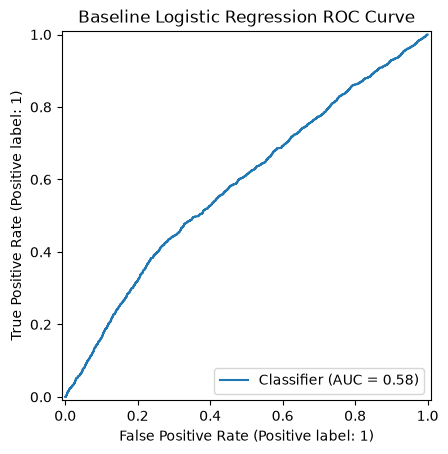

In [245]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, pred_probs)

plt.title("Baseline Logistic Regression ROC Curve")
plt.savefig("../outputs/figures/baseline_roc_curve.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [246]:
[col for col in pbp.columns if "pressure" in col.lower()]

[]

In [247]:
[col for col in pbp.columns if "epa" in col.lower()]

['epa',
 'total_home_epa',
 'total_away_epa',
 'total_home_rush_epa',
 'total_away_rush_epa',
 'total_home_pass_epa',
 'total_away_pass_epa',
 'air_epa',
 'yac_epa',
 'comp_air_epa',
 'comp_yac_epa',
 'total_home_comp_air_epa',
 'total_away_comp_air_epa',
 'total_home_comp_yac_epa',
 'total_away_comp_yac_epa',
 'total_home_raw_air_epa',
 'total_away_raw_air_epa',
 'total_home_raw_yac_epa',
 'total_away_raw_yac_epa',
 'qb_epa',
 'xyac_epa']

## Initial Findings

A baseline logistic regression model using only game variables achieved an ROC-AUC of 0.584.

This suggests that situational factors alone provide limited predictive power for sack prediction. Future iterations will incorporate quarterback tendencies, offensive line performance, pass rush strength, and team level historical metrics.

## 7. Feature Engineering: Team and Quarterback Context

The baseline model only used game state features. To improve predictive power, this section adds team and quarterback context, including offensive team, defensive team, and passer identity.

In [248]:
# Add categorical football context features
improved_features = features + [
    "posteam",
    "defteam",
    "passer_player_id"
]

improved_df = model_df[["sack"] + improved_features].dropna()

print(improved_df.shape)
improved_df.head()

(61841, 12)


,sack,down,ydstogo,yardline_100,qtr,game_seconds_remaining,week,xpass,pass_oe,posteam,defteam,passer_player_id
3,0.0,2.0,13,78.0,1,3563.0,1,0.697346,30.265415,TEN,ARI,00-0029701
4,0.0,3.0,10,75.0,1,3522.0,1,0.978253,2.174652,TEN,ARI,00-0029701
6,0.0,1.0,10,61.0,1,3507.0,1,0.458989,54.101130,ARI,TEN,00-0035228
8,0.0,1.0,18,31.0,1,3446.0,1,0.684949,31.505138,ARI,TEN,00-0035228
9,0.0,2.0,17,30.0,1,3414.0,1,0.775463,22.453719,ARI,TEN,00-0035228


# 8. Improved Logistic Regression

Train a logistic regression model using both game-state variables and categorical football context features.

One-hot encoding is applied to team and quarterback identifiers so the model can learn player and team specific tendencies.

In [249]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

numeric_features = features
categorical_features = ["posteam", "defteam", "passer_player_id"]

improved_features = features + categorical_features

improved_df = model_df[["sack", "season"] + improved_features].dropna()

train_df = improved_df[improved_df["season"] < 2023]
test_df = improved_df[improved_df["season"] == 2023]

X_train = train_df[improved_features]
X_test = test_df[improved_features]

y_train = train_df["sack"]
y_test = test_df["sack"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

improved_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

improved_model.fit(X_train, y_train)

improved_pred_probs = improved_model.predict_proba(X_test)[:, 1]

improved_auc = roc_auc_score(y_test, improved_pred_probs)

print(f"Improved Logistic Regression AUC: {improved_auc:.3f}")

Improved Logistic Regression AUC: 0.598


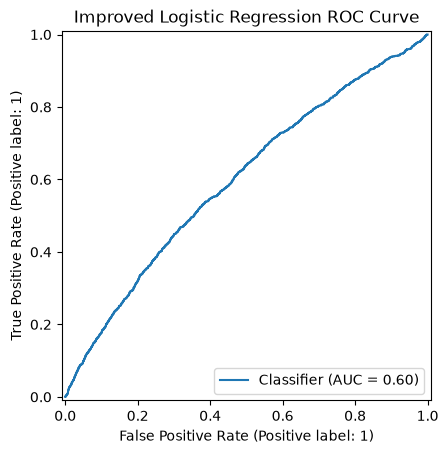

In [250]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    improved_pred_probs
)

plt.title("Improved Logistic Regression ROC Curve")
plt.savefig("../outputs/figures/improved_roc_curve.png",
            bbox_inches="tight")
plt.show()

# 9. Historical Sack Tendencies

Quarterbacks, offenses, and defenses have persistent tendencies related to sacks.

This section calculates historical sack rates using only training-season data (2021-2022) to avoid data leakage.

In [251]:
# Create historical rates using only training seasons
historical_df = model_df[model_df["season"] < 2023].copy()

league_sack_rate = historical_df["sack"].mean()

qb_sack_rates = (
    historical_df.groupby("passer_player_name")["sack"]
    .mean()
    .reset_index()
    .rename(columns={"sack": "qb_sack_rate"})
)

offense_sack_rates = (
    historical_df.groupby("posteam")["sack"]
    .mean()
    .reset_index()
    .rename(columns={"sack": "offense_sack_rate"})
)

defense_sack_rates = (
    historical_df.groupby("defteam")["sack"]
    .mean()
    .reset_index()
    .rename(columns={"sack": "defense_sack_rate"})
)

model_df = model_df.drop(
    columns=[
        "qb_sack_rate", "offense_sack_rate", "defense_sack_rate",
        "qb_sack_rate_x", "qb_sack_rate_y",
        "offense_sack_rate_x", "offense_sack_rate_y",
        "defense_sack_rate_x", "defense_sack_rate_y"
    ],
    errors="ignore"
)

model_df = model_df.merge(qb_sack_rates, on="passer_player_name", how="left")
model_df = model_df.merge(offense_sack_rates, on="posteam", how="left")
model_df = model_df.merge(defense_sack_rates, on="defteam", how="left")

model_df["qb_sack_rate"] = model_df["qb_sack_rate"].fillna(league_sack_rate)
model_df["offense_sack_rate"] = model_df["offense_sack_rate"].fillna(league_sack_rate)
model_df["defense_sack_rate"] = model_df["defense_sack_rate"].fillna(league_sack_rate)

model_df[[
    "qb_sack_rate",
    "offense_sack_rate",
    "defense_sack_rate"
]].isnull().sum()

qb_sack_rate         0
offense_sack_rate    0
defense_sack_rate    0
dtype: int64

# 10. Historical Sack Rate Model

Incorporate historical quarterback, offensive, and defensive sack rates into the feature set and evaluate their predictive value.

These features provide a direct measure of past sack performance beyond game-state information alone.

In [252]:
features_v3 = features + [
    "qb_sack_rate",
    "offense_sack_rate",
    "defense_sack_rate"
]

train_df = model_df[model_df["season"] < 2023]
test_df = model_df[model_df["season"] == 2023]

X_train = train_df[features_v3]
X_test = test_df[features_v3]

y_train = train_df["sack"]
y_test = test_df["sack"]

model_v3 = LogisticRegression(max_iter=1000)

model_v3.fit(X_train, y_train)

pred_probs_v3 = model_v3.predict_proba(X_test)[:, 1]

auc_v3 = roc_auc_score(y_test, pred_probs_v3)

print(f"Historical Sack Rate Model AUC: {auc_v3:.3f}")

Historical Sack Rate Model AUC: 0.606


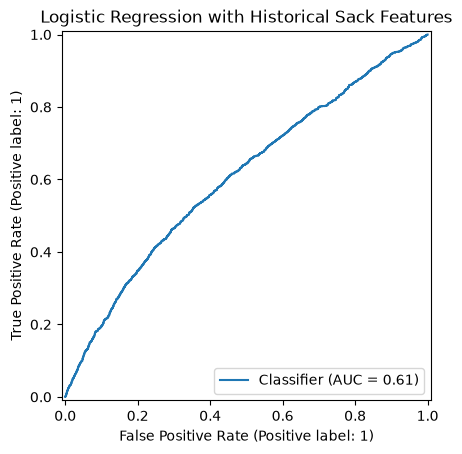

In [253]:
RocCurveDisplay.from_predictions(
    y_test,
    pred_probs_v3
)

plt.title("Logistic Regression with Historical Sack Features")
plt.savefig(
    "../outputs/figures/historical_features_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 11. Model Comparison

Compare the predictive performance of each modeling approach to determine which features provide the greatest improvement in sack prediction.

In [254]:
results = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Team + QB Features",
        "Historical Sack Rates"
    ],
    "ROC_AUC": [
        auc,
        improved_auc,
        auc_v3
    ]
})

results = results.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

results

,Model,ROC_AUC
0,Historical Sack Rates,0.605775
1,Team + QB Features,0.597577
2,Baseline Logistic Regression,0.584396


## 12. Pre Snap and Rolling Sack Risk Features

Up to this point, the best model uses historical quarterback, offense, and defense sack rates. That improved performance, but those rates are still broad season level summaries.

The next step is to make the model more realistic for the actual goal: predicting the probability that the next pass play will result in a sack.

To do this, we will add features that would be known before the snap, including:
- game situation
- shotgun/no-huddle indicators
- score differential
- rolling quarterback sack tendency
- rolling offensive sack tendency
- rolling defensive sack tendency
- matchup-based sack risk

These features are designed to represent the context a team would have before a pass play occurs.

In [255]:
section12_df = model_df.copy()

presnap_features = [
    "down",
    "ydstogo",
    "yardline_100",
    "qtr",
    "game_seconds_remaining",
    "week",
    "shotgun",
    "no_huddle",
    "score_differential",
    "posteam_score",
    "defteam_score",
    "xpass",
    "pass_oe"
]

section12_df[presnap_features + ["sack"]].isnull().sum()

down                      0
ydstogo                   0
yardline_100              0
qtr                       0
game_seconds_remaining    0
week                      0
shotgun                   0
no_huddle                 0
score_differential        0
posteam_score             0
defteam_score             0
xpass                     0
pass_oe                   0
sack                      0
dtype: int64

### 12.1 Add Matchup Based Sack Risk Features

Sacks are heavily influenced by matchups. A sack prone quarterback facing a strong pass rushing defense should have a higher expected sack probability than either factor alone would suggest.

We create interaction features between quarterback, offense, and defense historical sack rates.

In [256]:
section12_df["qb_vs_def_sack_risk"] = (
    section12_df["qb_sack_rate"] * section12_df["defense_sack_rate"]
)

section12_df["offense_vs_def_sack_risk"] = (
    section12_df["offense_sack_rate"] * section12_df["defense_sack_rate"]
)

section12_df[[
    "qb_sack_rate",
    "offense_sack_rate",
    "defense_sack_rate",
    "qb_vs_def_sack_risk",
    "offense_vs_def_sack_risk"
]].head()

,qb_sack_rate,offense_sack_rate,defense_sack_rate,qb_vs_def_sack_risk,offense_vs_def_sack_risk
0,0.084463,0.079835,0.056893,0.004805,0.004542
1,0.084463,0.079835,0.056893,0.004805,0.004542
2,0.060417,0.057275,0.058073,0.003509,0.003326
3,0.060417,0.057275,0.058073,0.003509,0.003326
4,0.060417,0.057275,0.058073,0.003509,0.003326


### 12.2 Create Rolling Sack Rate Features

The previous historical sack rate features only used 2021-2022 data. That is useful, but during a season, teams would also know what has happened recently.

To better simulate real prediction, we create rolling sack rates using only plays that occurred before the current play.

In [257]:
# Sort plays chronologically
section12_df = section12_df.sort_values(
    ["season", "week", "game_id", "play_id"]
).copy()

# Rolling QB sack rate within the current season before the current play
section12_df["qb_season_rolling_sack_rate"] = (
    section12_df
    .groupby(["season", "passer_player_id"])["sack"]
    .transform(lambda x: x.shift().expanding().mean())
)

# Rolling offensive sack rate within the current season before the current play
section12_df["offense_season_rolling_sack_rate"] = (
    section12_df
    .groupby(["season", "posteam"])["sack"]
    .transform(lambda x: x.shift().expanding().mean())
)

# Rolling defensive sack rate within the current season before the current play
section12_df["defense_season_rolling_sack_rate"] = (
    section12_df
    .groupby(["season", "defteam"])["sack"]
    .transform(lambda x: x.shift().expanding().mean())
)

# Fill early-season missing values with league average
league_sack_rate = section12_df["sack"].mean()

rolling_cols = [
    "qb_season_rolling_sack_rate",
    "offense_season_rolling_sack_rate",
    "defense_season_rolling_sack_rate"
]

section12_df[rolling_cols] = section12_df[rolling_cols].fillna(league_sack_rate)

section12_df[rolling_cols].isnull().sum()

qb_season_rolling_sack_rate         0
offense_season_rolling_sack_rate    0
defense_season_rolling_sack_rate    0
dtype: int64

### 12.3 Build the Section 12 Feature Set

This feature set combines:
- pre-snap game context
- historical sack tendencies
- rolling sack tendencies
- matchup interaction features

This gets the model much closer to the real task of estimating sack probability before the next pass play.

In [258]:
features_v4 = presnap_features + [
    "qb_sack_rate",
    "offense_sack_rate",
    "defense_sack_rate",
    "qb_vs_def_sack_risk",
    "offense_vs_def_sack_risk",
    "qb_season_rolling_sack_rate",
"offense_season_rolling_sack_rate",
"defense_season_rolling_sack_rate"
]

section12_model_df = section12_df[
    ["sack", "season"] + features_v4
].dropna()

train_df = section12_model_df[section12_model_df["season"] < 2023]
test_df = section12_model_df[section12_model_df["season"] == 2023]

X_train = train_df[features_v4]
X_test = test_df[features_v4]

y_train = train_df["sack"]
y_test = test_df["sack"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Sack rate in train:", y_train.mean())
print("Sack rate in test:", y_test.mean())

Train shape: (45338, 21)
Test shape: (22864, 21)
Sack rate in train: 0.058913053068066525
Sack rate in test: 0.06381210636808958


## 13. Logistic Regression with Pre Snap Features

The Section 12 feature engineering process introduced:

- historical sack tendencies
- season-to-date rolling sack tendencies
- matchup-based sack risk features
- additional pre-snap game context

We evaluate whether these features improve predictive performance compared to previous models.

In [259]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model_v4 = LogisticRegression(
    max_iter=5000
)

model_v4.fit(X_train, y_train)

pred_probs_v4 = model_v4.predict_proba(X_test)[:,1]

auc_v4 = roc_auc_score(
    y_test,
    pred_probs_v4
)

print(f"Section 12 Feature Model AUC: {auc_v4:.3f}")

Section 12 Feature Model AUC: 0.611


\\s5az.az.local\user$\efriedman\Desktop\SwishAnalyticsDataModelingChallenge\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


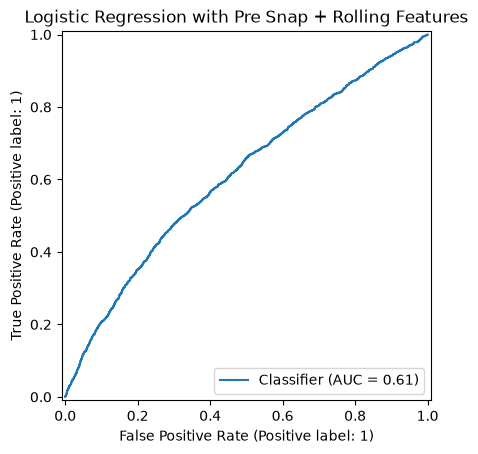

In [260]:
RocCurveDisplay.from_predictions(
    y_test,
    pred_probs_v4
)

plt.title("Logistic Regression with Pre Snap + Rolling Features")
plt.savefig(
    "../outputs/figures/rolling_features_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [261]:
coef_df = pd.DataFrame({
    "feature": features_v4,
    "coefficient": model_v4.coef_[0]
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()

coef_df = (
    coef_df
    .sort_values("abs_coef", ascending=False)
)

coef_df.head(15)

,feature,coefficient,abs_coef
13,qb_sack_rate,6.111999,6.111999
14,offense_sack_rate,1.647970,1.647970
11,xpass,-1.596630,1.596630
18,qb_season_rolling_sack_rate,1.138496,1.138496
19,offense_season_rolling_sack_rate,0.736415,0.736415
15,defense_sack_rate,0.687754,0.687754
16,qb_vs_def_sack_risk,0.413806,0.413806
7,no_huddle,-0.326962,0.326962
6,shotgun,-0.306106,0.306106
0,down,0.166664,0.166664


## Model Comparison

In [262]:
results = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Team + QB Features",
        "Historical Sack Rates",
        "Pre Snap + Rolling Features"
    ],
    "ROC_AUC": [
        auc,
        improved_auc,
        auc_v3,
        auc_v4
    ]
})

results = results.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

results

,Model,ROC_AUC
0,Pre Snap + Rolling Features,0.611031
1,Historical Sack Rates,0.605775
2,Team + QB Features,0.597577
3,Baseline Logistic Regression,0.584396


## 14. Gradient Boosting Model

The logistic regression model improved slightly after adding pre snap and rolling sack risk features, but the feature set contains nonlinear relationships and overlapping signals.

A gradient boosting model is a better fit because it can capture interactions between quarterback sack tendency, defensive sack tendency, down, distance, game script, and other pre snap variables.

In [263]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

gb_model = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=200,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_probs = gb_model.predict_proba(X_test)[:, 1]

gb_auc = roc_auc_score(y_test, gb_probs)

print(f"Gradient Boosting AUC: {gb_auc:.3f}")

Gradient Boosting AUC: 0.594


Gradient Boost is not where we want it to be, need to combine more features to try and get the best outcome.

## 15. Weekly Quarterback and Defensive Pressure Metrics

So far, the model has used play level context, historical sack rates, and rolling sack tendencies. These features improved performance, but they still do not directly measure pressure.

This section adds weekly advanced statistics for quarterbacks and defenses. These features help capture:

- how often a quarterback is pressured
- how often a quarterback is sacked
- how often a defense creates sacks
- how often a defense creates pressure

To keep the model realistic, all weekly advanced stat features are shifted by one week. This means each play only uses information that would have been known before that game was played.

In [264]:
# Load weekly advanced passing stats
pass_adv = pd.concat([
    pd.read_csv(f"{DATA_PATH}/advstats_week_pass_2021.csv"),
    pd.read_csv(f"{DATA_PATH}/advstats_week_pass_2022.csv"),
    pd.read_csv(f"{DATA_PATH}/advstats_week_pass_2023.csv")
], ignore_index=True)

# Load weekly advanced defensive stats
def_adv = pd.concat([
    pd.read_csv(f"{DATA_PATH}/advstats_week_def_2021.csv"),
    pd.read_csv(f"{DATA_PATH}/advstats_week_def_2022.csv"),
    pd.read_csv(f"{DATA_PATH}/advstats_week_def_2023.csv")
], ignore_index=True)

print("Passing advanced stats shape:", pass_adv.shape)
print("Defensive advanced stats shape:", def_adv.shape)

Passing advanced stats shape: (2091, 24)
Defensive advanced stats shape: (24222, 29)


### 15.1 Inspect Advanced Statistic Columns

Before creating features, we inspect the available columns to confirm which pressure-related metrics can be used.

In [265]:
print("Passing advanced stats columns:")
print(pass_adv.columns.tolist())

print("\nDefensive advanced stats columns:")
print(def_adv.columns.tolist())

Passing advanced stats columns:
['game_id', 'pfr_game_id', 'season', 'week', 'game_type', 'team', 'opponent', 'pfr_player_name', 'pfr_player_id', 'passing_drops', 'passing_drop_pct', 'receiving_drop', 'receiving_drop_pct', 'passing_bad_throws', 'passing_bad_throw_pct', 'times_sacked', 'times_blitzed', 'times_hurried', 'times_hit', 'times_pressured', 'times_pressured_pct', 'def_times_blitzed', 'def_times_hurried', 'def_times_hitqb']

Defensive advanced stats columns:
['game_id', 'pfr_game_id', 'season', 'week', 'game_type', 'team', 'opponent', 'pfr_player_name', 'pfr_player_id', 'def_ints', 'def_targets', 'def_completions_allowed', 'def_completion_pct', 'def_yards_allowed', 'def_yards_allowed_per_cmp', 'def_yards_allowed_per_tgt', 'def_receiving_td_allowed', 'def_passer_rating_allowed', 'def_adot', 'def_air_yards_completed', 'def_yards_after_catch', 'def_times_blitzed', 'def_times_hurried', 'def_times_hitqb', 'def_sacks', 'def_pressures', 'def_tackles_combined', 'def_missed_tackles', 'd

In [266]:
pass_adv[[
    "season",
    "week",
    "team",
    "opponent",
    "pfr_player_name",
    "pfr_player_id",
    "times_sacked",
    "times_blitzed",
    "times_hurried",
    "times_hit",
    "times_pressured",
    "times_pressured_pct"
]].head()

,season,week,team,opponent,pfr_player_name,pfr_player_id,times_sacked,times_blitzed,times_hurried,times_hit,times_pressured,times_pressured_pct
0,2021,1,TB,DAL,Tom Brady,BradTo00,0,11,1,2,3,0.060
1,2021,1,DAL,TB,Dak Prescott,PresDa01,1,32,2,6,9,0.145
2,2021,1,ATL,PHI,Matt Ryan,RyanMa00,3,4,3,6,12,0.308
3,2021,1,PHI,ATL,Jalen Hurts,HurtJa00,1,14,4,1,6,0.154
4,2021,1,BUF,PIT,Josh Allen,AlleJo02,3,1,11,5,19,0.345


In [267]:
def_adv[[
    "season",
    "week",
    "team",
    "opponent",
    "def_sacks",
    "def_pressures",
    "def_times_blitzed",
    "def_times_hurried",
    "def_times_hitqb"
]].head()

,season,week,team,opponent,def_sacks,def_pressures,def_times_blitzed,def_times_hurried,def_times_hitqb
0,2021,1,TB,DAL,0.0,0,7,0,0
1,2021,1,TB,DAL,0.0,1,8,0,1
2,2021,1,TB,DAL,0.0,0,1,0,0
3,2021,1,TB,DAL,0.0,0,0,0,0
4,2021,1,TB,DAL,0.0,0,2,0,0


### 15.2 Create Prior-Week Quarterback Pressure Features

The passing advanced stat file contains weekly quarterback pressure information.

To avoid data leakage, we shift each quarterback's weekly values by one week within each season. For example, a Week 6 play can use the quarterback's Week 5 pressure stats, but not Week 6 results.

In [268]:
# Aggregate QB passing advanced stats to one row per team-week
qb_team_week = (
    pass_adv
    .groupby(["season", "week", "team"], as_index=False)[
        [
            "times_sacked",
            "times_blitzed",
            "times_hurried",
            "times_hit",
            "times_pressured",
            "times_pressured_pct"
        ]
    ]
    .mean()
)

qb_team_week = qb_team_week.sort_values(
    ["team", "season", "week"]
).copy()

qb_adv_features = [
    "times_sacked",
    "times_blitzed",
    "times_hurried",
    "times_hit",
    "times_pressured",
    "times_pressured_pct"
]

for col in qb_adv_features:
    qb_team_week[f"qb_prev_{col}"] = (
        qb_team_week
        .groupby(["team", "season"])[col]
        .shift(1)
    )

qb_prev_cols = [f"qb_prev_{col}" for col in qb_adv_features]

qb_weekly_features = qb_team_week[
    ["season", "week", "team"] + qb_prev_cols
].copy()

qb_weekly_features.head()

,season,week,team,qb_prev_times_sacked,qb_prev_times_blitzed,qb_prev_times_hurried,qb_prev_times_hit,qb_prev_times_pressured,qb_prev_times_pressured_pct
0,2021,1,ARI,NaN,NaN,NaN,NaN,NaN,NaN
32,2021,2,ARI,2.0,7.0,5.0,2.0,9.0,0.257
64,2021,3,ARI,3.0,6.0,6.0,0.0,9.0,0.220
96,2021,4,ARI,0.0,4.0,0.0,1.0,1.0,0.027
128,2021,5,ARI,3.0,7.0,8.0,0.0,11.0,0.282


### 15.3 Create Prior-Week Defensive Pressure Features

The defensive advanced-stat file contains weekly team pass-rush metrics.

Again, each defensive metric is shifted by one week within each team-season so the model only uses information available before the game.

In [269]:
# Aggregate defense advanced stats to one row per team/week
def_team_week = (
    def_adv
    .groupby(["season", "week", "team"], as_index=False)[
        [
            "def_sacks",
            "def_pressures",
            "def_times_blitzed",
            "def_times_hurried",
            "def_times_hitqb"
        ]
    ]
    .sum()
)

def_team_week = def_team_week.sort_values(
    ["team", "season", "week"]
).copy()

def_adv_features = [
    "def_sacks",
    "def_pressures",
    "def_times_blitzed",
    "def_times_hurried",
    "def_times_hitqb"
]

# Create previous-week defensive features
for col in def_adv_features:
    def_team_week[f"prev_{col}"] = (
        def_team_week
        .groupby(["team", "season"])[col]
        .shift(1)
    )

def_prev_cols = [f"prev_{col}" for col in def_adv_features]

def_weekly_features = def_team_week[
    ["season", "week", "team"] + def_prev_cols
].copy()

def_weekly_features.head()

,season,week,team,prev_def_sacks,prev_def_pressures,prev_def_times_blitzed,prev_def_times_hurried,prev_def_times_hitqb
0,2021,1,ARI,NaN,NaN,NaN,NaN,NaN
32,2021,2,ARI,6.0,12.0,4.0,1.0,5.0
64,2021,3,ARI,1.0,7.0,39.0,2.0,4.0
96,2021,4,ARI,2.0,10.0,13.0,4.0,4.0
128,2021,5,ARI,0.0,8.0,12.0,3.0,5.0


### 15.4 Merge Advanced Stats into the Play-Level Dataset

Next, we merge the weekly quarterback and defensive pressure features into the play level modeling dataset.

The quarterback advanced features are merged using season, week, offensive team, and quarterback identifier.

The defensive advanced features are merged using season, week, and defensive team.

In [270]:
section15_df = section12_df.copy()

print("Before merge:", section15_df.shape)

# Merge previous-week offensive/QB pressure stats by offensive team
section15_df = section15_df.merge(
    qb_weekly_features,
    left_on=["season", "week", "posteam"],
    right_on=["season", "week", "team"],
    how="left"
)

section15_df = section15_df.drop(
    columns=["team"],
    errors="ignore"
)

print("After QB/team merge:", section15_df.shape)

# Merge previous-week defensive pressure stats
section15_df = section15_df.merge(
    def_weekly_features,
    left_on=["season", "week", "defteam"],
    right_on=["season", "week", "team"],
    how="left"
)

section15_df = section15_df.drop(
    columns=["team"],
    errors="ignore"
)

print("After defense merge:", section15_df.shape)

Before merge: (68202, 380)
After QB/team merge: (68202, 386)
After defense merge: (68202, 391)


### 15.5 Handle Missing Advanced Statistic Values

Some rows may not have matching advanced stat data. This can happen because of player ID differences, low playing time, missing weekly rows, or Week 1 having no previous week values.

We fill missing advanced stat features with the training set averages so the model can still generate predictions for all pass plays.

In [271]:
advanced_feature_cols = qb_prev_cols + def_prev_cols

train_mask = section15_df["season"] < 2023

for col in advanced_feature_cols:
    train_mean = section15_df.loc[train_mask, col].mean()
    section15_df[col] = section15_df[col].fillna(train_mean)

section15_df[advanced_feature_cols].isnull().sum()

qb_prev_times_sacked           0
qb_prev_times_blitzed          0
qb_prev_times_hurried          0
qb_prev_times_hit              0
qb_prev_times_pressured        0
qb_prev_times_pressured_pct    0
prev_def_sacks                 0
prev_def_pressures             0
prev_def_times_blitzed         0
prev_def_times_hurried         0
prev_def_times_hitqb           0
dtype: int64

### 15.6 Build the Advanced Stats Feature Set

This model combines the strongest features from previous sections with the new advanced quarterback and defensive pressure metrics.

This keeps the project moving toward the final goal: estimating sack probability before the next pass play.

In [272]:
features_v5 = [

    # Game state
    "down",
    "ydstogo",
    "yardline_100",
    "qtr",
    "game_seconds_remaining",
    "week",
    "xpass",
    "pass_oe",
    "shotgun",

    # Historical sack tendencies
    "qb_sack_rate",
    "offense_sack_rate",
    "defense_sack_rate",

    # Rolling season-to-date sack tendencies
    "qb_season_rolling_sack_rate",
    "offense_season_rolling_sack_rate",
    "defense_season_rolling_sack_rate",

    # Matchup features
    "qb_vs_def_sack_risk",
    "offense_vs_def_sack_risk",

    # Advanced QB pressure features
    "qb_prev_times_sacked",
    "qb_prev_times_blitzed",
    "qb_prev_times_hurried",
    "qb_prev_times_hit",
    "qb_prev_times_pressured",
    "qb_prev_times_pressured_pct",

    # Advanced defensive pressure features
    "prev_def_sacks",
    "prev_def_pressures",
    "prev_def_times_blitzed",
    "prev_def_times_hurried",
    "prev_def_times_hitqb"
]

section15_model_df = section15_df[
    ["sack", "season"] + features_v5
].dropna()

train_df = section15_model_df[section15_model_df["season"] < 2023]
test_df = section15_model_df[section15_model_df["season"] == 2023]

X_train = train_df[features_v5]
X_test = test_df[features_v5]

y_train = train_df["sack"]
y_test = test_df["sack"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train sack rate:", y_train.mean())
print("Test sack rate:", y_test.mean())

Train shape: (45338, 28)
Test shape: (22864, 28)
Train sack rate: 0.058913053068066525
Test sack rate: 0.06381210636808958


At this point, the dataset includes game context, historical sack tendencies, rolling season tendencies, matchup features, and weekly advanced pressure statistics. The next step is to evaluate whether these advanced features improve sack prediction performance.

## 16. Evaluating Advanced Pressure Features

The previous sections established that quarterback tendencies, offensive tendencies, defensive tendencies, and game state context all contribute to sack probability.

This section evaluates whether weekly advanced pressure metrics provide additional predictive power beyond historical sack rates and rolling season features.

These features more directly measure a quarterback's exposure to pressure and a defense's ability to generate pressure, bringing the model closer to the real world problem of predicting whether the next pass play will result in a sack.

In [273]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model_v5 = LogisticRegression(
    max_iter=5000
)

model_v5.fit(X_train, y_train)

pred_probs_v5 = model_v5.predict_proba(X_test)[:, 1]

auc_v5 = roc_auc_score(
    y_test,
    pred_probs_v5
)

print(f"Advanced Pressure Feature Model AUC: {auc_v5:.3f}")

Advanced Pressure Feature Model AUC: 0.614


\\s5az.az.local\user$\efriedman\Desktop\SwishAnalyticsDataModelingChallenge\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


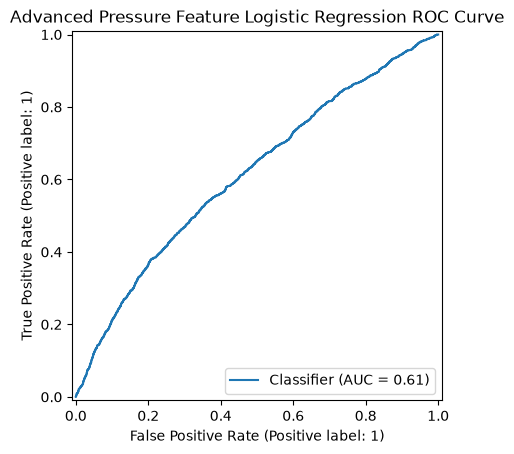

In [274]:
RocCurveDisplay.from_predictions(
    y_test,
    pred_probs_v5
)

plt.title("Advanced Pressure Feature Logistic Regression ROC Curve")
plt.savefig(
    "../outputs/figures/advanced_pressure_features_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 16.1 Feature Importance

To better understand which factors contribute most to sack probability, we examine the model coefficients.

This provides insight into which quarterback, offensive, defensive, and situational variables are most associated with sacks.

In [275]:
coef_df = pd.DataFrame({
    "feature": features_v5,
    "coefficient": model_v5.coef_[0]
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values(
    "abs_coef",
    ascending=False
)

coef_df.head(20)

,feature,coefficient,abs_coef
9,qb_sack_rate,4.087131,4.087131
6,xpass,-1.256309,1.256309
12,qb_season_rolling_sack_rate,1.071688,1.071688
10,offense_sack_rate,1.069183,1.069183
13,offense_season_rolling_sack_rate,0.640110,0.640110
11,defense_sack_rate,0.366764,0.366764
8,shotgun,-0.335305,0.335305
15,qb_vs_def_sack_risk,0.271245,0.271245
0,down,0.191900,0.191900
3,qtr,-0.091470,0.091470


### 16.2 Model Comparison

We compare all models developed throughout the project to evaluate the impact of additional football specific features.

In [276]:
results = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Team + QB Context",
        "Historical Sack Tendencies",
        "Pre Snap + Rolling Features",
        "Advanced Pressure Features"
    ],
    "ROC_AUC": [
        auc,
        improved_auc,
        auc_v3,
        auc_v4,
        auc_v5
    ]
})

results.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,ROC_AUC
4,Advanced Pressure Features,0.614180
3,Pre Snap + Rolling Features,0.611031
2,Historical Sack Tendencies,0.605775
1,Team + QB Context,0.597577
0,Baseline Logistic Regression,0.584396
